# 作业 1 

## 2.1 理论计算题

已知：  
a = [2, -1, 3]^T  
b = [1, 4, -2]^T  

A = [[1, 0, 2], [-1, 3, 1]]  
B = [[2,1],[0,-1],[3,2]]  

### (1) 向量点积
a·b = 2×1 + (-1)×4 + 3×(-2) = 2 - 4 - 6 = -8  

### (2) 矩阵乘法
A (2×3) × B (3×2) → 结果为 (2×2)

计算结果：  
[[1×2+0×0+2×3, 1×1+0×(-1)+2×2],  
 [-1×2+3×0+1×3, -1×1+3×(-1)+1×2]]  

= [[8,5],[1,-2]]  

### (3) Frobenius 范数
||a|| = sqrt(2² + (-1)² + 3²) = sqrt(14)


## 2.2

In [2]:
import numpy as np

X = np.random.randn(3,4)
Y = np.ones((4,2))

Z = X @ Y

print("Z =\n", Z)
print("Z[0,1] =", Z[0,1])
print("Z 第2行 =", Z[1])
print("Frobenius 范数 =", np.linalg.norm(Z))

Z =
 [[ 4.89908506  4.89908506]
 [-3.83489649 -3.83489649]
 [ 1.33163442  1.33163442]]
Z[0,1] = 4.899085056698765
Z 第2行 = [-3.83489649 -3.83489649]
Frobenius 范数 = 8.997857044539357


## 3.1 贝叶斯计算

P(患病)=0.001  
P(阳性|患病)=0.99  
P(阳性|未患病)=0.02  

贝叶斯公式：  
P(患病|阳性) = (0.99×0.001) / (0.99×0.001 + 0.02×0.999)

≈ 0.047约 4.7%


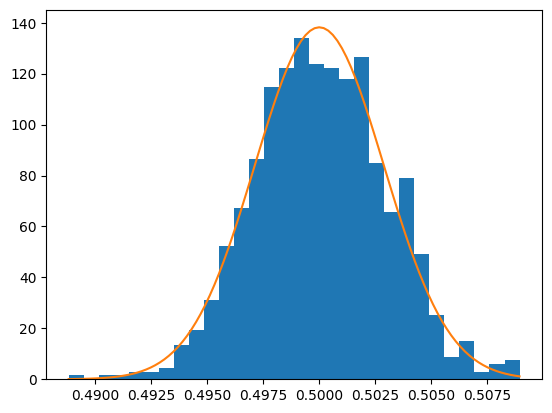

方差 = 8.654325010185085e-06


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

n=10000
m=1000

means = [np.mean(np.random.uniform(0,1,n)) for _ in range(m)]

plt.hist(means, bins=30, density=True)

mu = 0.5
sigma = np.sqrt(1/(12*n))

x = np.linspace(min(means), max(means), 100)
plt.plot(x, norm.pdf(x, mu, sigma))

plt.show()

print("方差 =", np.var(means))

## 4.1 反向传播

z = (w1x1 + w2x2 - y)^2  

∂z/∂w1 = 2(w1x1 + w2x2 - y)x1  
∂z/∂w2 = 2(w1x1 + w2x2 - y)x2  

代入：x1=2,x2=1,y=3,w1=0.5,w2=1  

∂z/∂w1 = -2×2 = -4  
∂z/∂w2 = -2×1 = -2

In [5]:
import torch

x = torch.tensor(2.0)
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)

a = x * w1
b = a + w2
L = b**2

L.backward()

print("w1 梯度:", w1.grad)
print("w2 梯度:", w2.grad)

w1 梯度: tensor(14.)
w2 梯度: tensor(7.)


## 5.1 线性回归

L = (1/n) Σ (yi - (wxi + b))^2  

∂L/∂w = -(2/n) Σ xi(yi - (wxi + b))  
∂L/∂b = -(2/n) Σ (yi - (wxi + b))


In [6]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import numpy as np

data = load_digits()
X = data.data
y = data.target

def softmax(z):
    exp = np.exp(z - np.max(z,axis=1,keepdims=True))
    return exp / np.sum(exp,axis=1,keepdims=True)

def one_hot(y, num_class):
    return np.eye(num_class)[y]

y_one = one_hot(y,10)

X_train,X_test,y_train,y_test = train_test_split(X,y_one,test_size=0.2)

w = np.random.randn(64,10)
b = np.zeros((1,10))

lr=0.1

for epoch in range(50):
    logits = X_train @ w + b
    probs = softmax(logits)
    
    grad_w = X_train.T @ (probs - y_train) / len(X_train)
    grad_b = np.mean(probs - y_train,axis=0,keepdims=True)
    
    w -= lr * grad_w
    b -= lr * grad_b

pred = np.argmax(softmax(X_test@w+b),axis=1)
true = np.argmax(y_test,axis=1)

print("准确率:", np.mean(pred==true))

准确率: 0.85


## 6.1 最大似然估计

似然函数：  
L(μ,σ²)= Π (1/√(2πσ²)) exp(-(xi-μ)^2/(2σ²))

正态分布的概率密度函数为：
$$f(x_i|\mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)$$

由于样本独立同分布，似然函数为：
$$L(\mu, \sigma^2) = \prod_{i=1}^n f(x_i|\mu, \sigma^2) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)$$

整理得：
$$L(\mu, \sigma^2) = (2\pi\sigma^2)^{-n/2} \exp\left(-\frac{1}{2\sigma^2}\sum_{i=1}^n (x_i - \mu)^2\right)$$

取对数得到对数似然函数

$$\ell(\mu, \sigma^2) = \ln L(\mu, \sigma^2) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln(\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n (x_i - \mu)^2$$


对 $\mu$ 求偏导数：
$$\frac{\partial \ell}{\partial \mu} = -\frac{1}{2\sigma^2} \cdot \frac{\partial}{\partial \mu}\sum_{i=1}^n (x_i - \mu)^2$$

由于 $\frac{\partial}{\partial \mu}(x_i - \mu)^2 = -2(x_i - \mu)$，所以：
$$\frac{\partial}{\partial \mu}\sum_{i=1}^n (x_i - \mu)^2 = -2\sum_{i=1}^n (x_i - \mu)$$

$$\frac{\partial \ell}{\partial \mu} = -\frac{1}{2\sigma^2} \cdot \left[-2\sum_{i=1}^n (x_i - \mu)\right] = \frac{1}{\sigma^2}\sum_{i=1}^n (x_i - \mu)$$

令偏导数为0：
$$\frac{1}{\sigma^2}\sum_{i=1}^n (x_i - \mu) = 0$$

由于 $\sigma^2 > 0$，有：
$$\sum_{i=1}^n (x_i - \mu) = 0$$

$$\sum_{i=1}^n x_i - n\mu = 0$$
解得：
$$\hat{\mu} = \frac{1}{n}\sum_{i=1}^n x_i$$



令 $v = \sigma^2$，对数似然函数为：
$$\ell(\mu, v) = -\frac{n}{2}\ln(2\pi) - \frac{n}{2}\ln v - \frac{1}{2v}\sum_{i=1}^n (x_i - \mu)^2$$

对 $v$ 求偏导数：
$$\frac{\partial \ell}{\partial v} = -\frac{n}{2v} + \frac{1}{2v^2}\sum_{i=1}^n (x_i - \mu)^2$$

令偏导数为0：
$$-\frac{n}{2v} + \frac{1}{2v^2}\sum_{i=1}^n (x_i - \mu)^2 = 0$$

两边乘以 $2v^2$：
$$-nv + \sum_{i=1}^n (x_i - \mu)^2 = 0$$

解得：
$$\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \mu)^2$$

将 $\mu$ 的估计值 $\hat{\mu}$ 代入：
$$\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \hat{\mu})^2$$

结论：  
μ̂ = (1/n) Σ xi  
σ̂² = (1/n) Σ (xi-μ̂)^2


测试准确率: 1.0


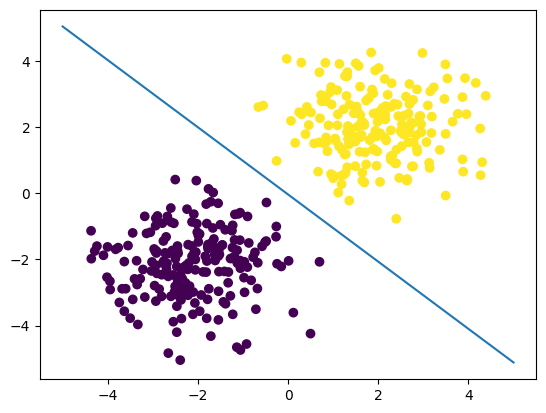

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1/(1+np.exp(-x))

# 生成数据
np.random.seed(0)
X1 = np.random.randn(200,2)+[2,2]
X2 = np.random.randn(200,2)+[-2,-2]

X = np.vstack((X1,X2))
y = np.hstack((np.ones(200), np.zeros(200)))

w = np.zeros(2)
b = 0

lr=0.1

for i in range(1000):
    z = X@w + b
    pred = sigmoid(z)
    
    grad_w = X.T@(pred-y)/len(X)
    grad_b = np.mean(pred-y)
    
    w -= lr*grad_w
    b -= lr*grad_b

# 测试
X_test = np.vstack((np.random.randn(50,2)+[2,2], np.random.randn(50,2)+[-2,-2]))
y_test = np.hstack((np.ones(50), np.zeros(50)))

pred = sigmoid(X_test@w+b) > 0.5

print("测试准确率:", np.mean(pred==y_test))

# 绘图
plt.scatter(X[:,0], X[:,1], c=y)
x_line = np.linspace(-5,5,100)
y_line = -(w[0]*x_line + b)/w[1]
plt.plot(x_line, y_line)
plt.show()